# <center>Segmentación de Clientes del Centro Comercial</center>

### Objetivo :
- Clasificar / agrupar clientes del centro comercial según características numéricas y categóricas.
- Es un problema de **Aprendizaje No Supervisado**.

### <center>Atributos del Conjunto de Datos</center>
    
- **CustomerID** : Identificador único asignado al cliente
- **Gender** : Género del cliente
- **Edad** : Edad del cliente
- **Annual Income (k\\$)** : Ingreso anual del cliente
- **Spending Score (1-100)** : Puntaje asignado por el centro comercial según el comportamiento y el patrón de gasto del cliente

## Datos del estudiante

- **Estudiante:** Uriel Abdallah Medina Torres
- **Grupo:** B
- **Asignatura:** Extracción de Conocimiento en Bases de Datos
- **Práctica:** 11 — Segmentación de clientes con K-Means
- **Fecha:** 18/08/2026

### Contenido del Notebook :
- Información del conjunto de datos
- Análisis Exploratorio de Datos (EDA)
- Resumen del EDA
- Ingeniería de Características
- Modelado
- Conclusión

### Qué aprenderás :
- Técnicas de visualización de datos.
- Información sobre el algoritmo de agrupamiento K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencia en el rendimiento del modelo cuando se entrena con el conjunto de datos original y normalizado.

### Trabajo reciente :

- [Clasificación Binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque requerido para resolver problemas de Clasificación Binaria explicado mediante notebooks con código claro y fácil de entender.**
- [Análisis de Series Temporales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los conceptos básicos del Análisis de Series Temporales explicado mediante notebooks con código claro y fácil de entender.**

### ¡Comencemos!

# <center>Información del Conjunto de Datos</center>

### Importar las librerías necesarias :

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

RANDOM_STATE = 42
N_INIT = 10
sns.set_theme(style='whitegrid')

In [5]:
data_path = Path('Mall_Customers.csv')
if not data_path.exists():
    data_path = Path('Practice-11/Mall_Customers.csv')

if not data_path.exists():
    raise FileNotFoundError('No se encontró Mall_Customers.csv')

data = pd.read_csv(data_path).rename(columns={'Genre': 'Gender'})
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Información de los datos :

In [6]:
data.shape

(200, 5)

In [7]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


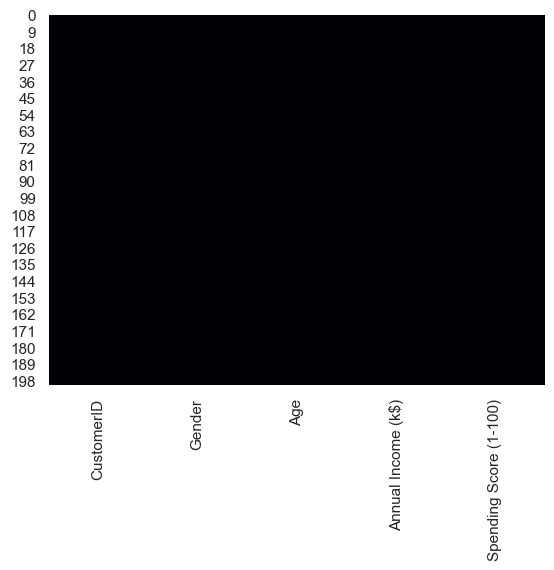

In [9]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- ¡No hay valores nulos presentes en los datos!

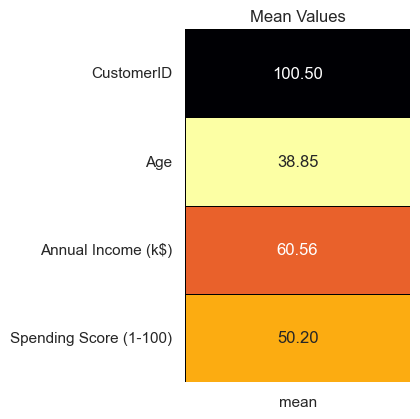

In [10]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 3)

- La edad promedio de los clientes en el conjunto de datos se encuentra en los últimos 30 años, es decir, **38.85**.
- El ingreso anual promedio de los clientes es **60.56**, ligeramente por debajo de la mediana de ingresos de EE. UU. en 2018 (63k$).
- El puntaje promedio de gasto (**Spending Score (1-100)**) de los clientes del centro comercial está en el centro con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### División de características en Numéricas y Categóricas :

In [11]:
# CustomerID es un identificador y no se utiliza como variable analítica.
categorical_features = ['Gender']
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

print('Características categóricas:', *categorical_features)
print('Características numéricas:', *numerical_features)

Características categóricas: Gender
Características numéricas: Age Annual Income (k$) Spending Score (1-100)


- Las variables se clasifican mediante su significado y tipo de dato, no por una cantidad arbitraria de valores únicos.
- **Gender** es la única característica categórica.
- **Age**, **Annual Income (k\$)** y **Spending Score (1-100)** son características numéricas.
- **CustomerID** se excluye del análisis porque es únicamente un identificador.

In [12]:
le = LabelEncoder()
df1 = data.copy(deep=True)
df1['Gender_encoded'] = le.fit_transform(df1['Gender'])

print('Codificación de Gender:')
for value, label in enumerate(le.classes_):
    print(f'{label} = {value}')

Codificación de Gender:
Female = 0
Male = 1


- Se crea una copia profunda del conjunto de datos original.
- **Gender** se conserva como texto para las visualizaciones y se añade **Gender_encoded** para la matriz de correlación.
- La variable categórica no se utiliza en los modelos K-Means posteriores.

### Distribución de características categóricas y numéricas :

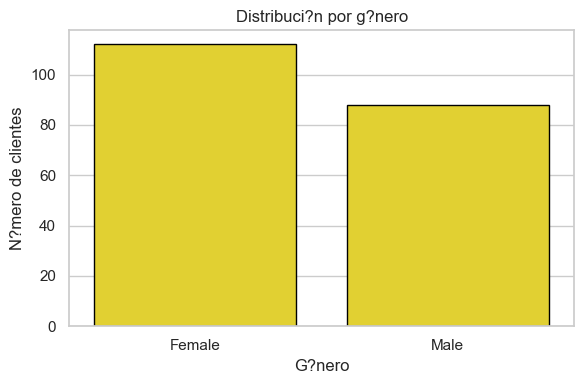

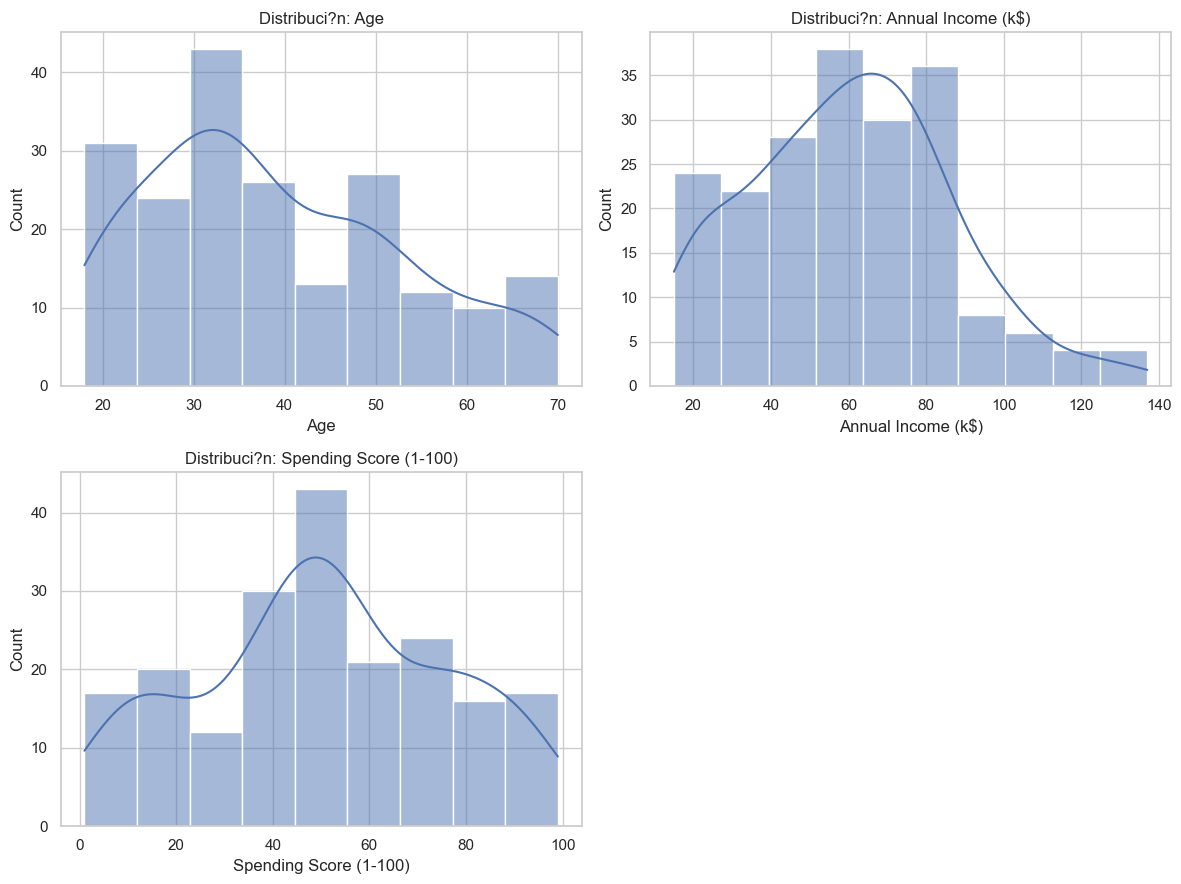

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df1, x='Gender', order=['Female', 'Male'], color='#FEE715', edgecolor='black', ax=ax)
ax.set_title('Distribución por género')
ax.set_xlabel('Género')
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, feature in zip(axes, numerical_features):
    sns.histplot(data=df1, x=feature, kde=True, ax=ax)
    ax.set_title(f'Distribución: {feature}')
for ax in axes[len(numerical_features):]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()

- **Gender** es una variable categórica con 112 mujeres (56 %) y 88 hombres (44 %); por ello no se describe como una distribución normal.
- **Age** presenta una asimetría positiva moderada y **Annual Income (k\$)** una asimetría positiva ligera.
- **Spending Score (1-100)** es prácticamente simétrica alrededor de su valor medio.
- **CustomerID** se excluye porque no representa una característica del cliente.

In [14]:
# La lista ya excluye CustomerID de forma explícita.
print('Variables utilizadas en el análisis:', numerical_features)

Variables utilizadas en el análisis: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


### Características Categóricas :

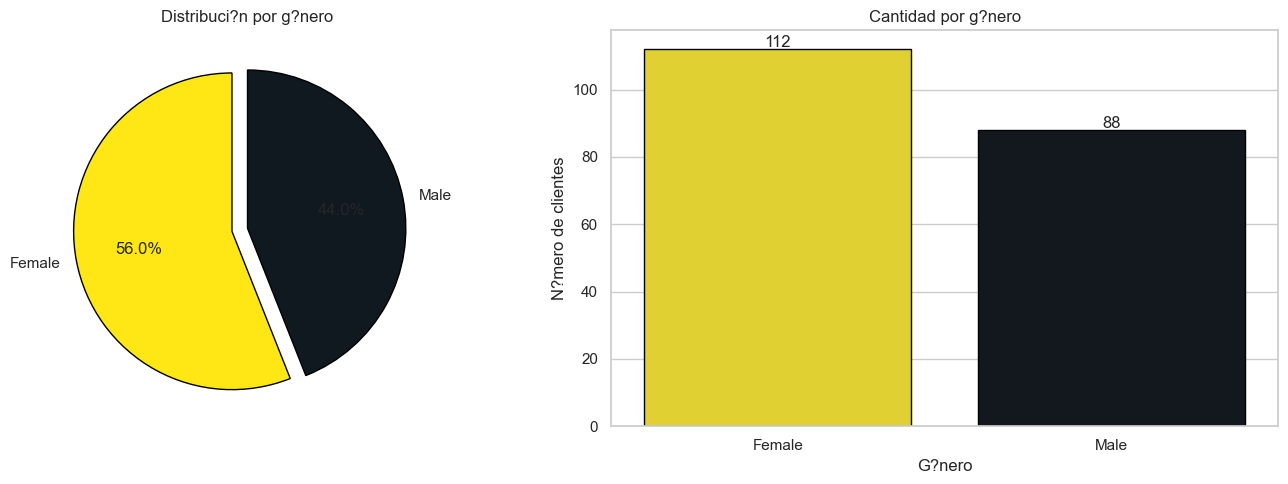

In [15]:
gender_counts = df1['Gender'].value_counts().reindex(['Female', 'Male'])
colors = ['#FEE715', '#101820']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].pie(
    gender_counts.values,
    labels=['Female', 'Male'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0),
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[0].set_title('Distribución por género')

sns.countplot(
    data=df1,
    x='Gender',
    order=['Female', 'Male'],
    hue='Gender',
    palette={'Female': colors[0], 'Male': colors[1]},
    legend=False,
    edgecolor='black',
    ax=axes[1]
)
for rect in axes[1].patches:
    axes[1].text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.75,
        int(rect.get_height()),
        ha='center'
    )
axes[1].set_title('Cantidad por género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()

- Para el conjunto de datos anterior, las clientes **femeninas** superan ligeramente a los clientes **masculinos**.

### Características Numéricas vs Características Categóricas :

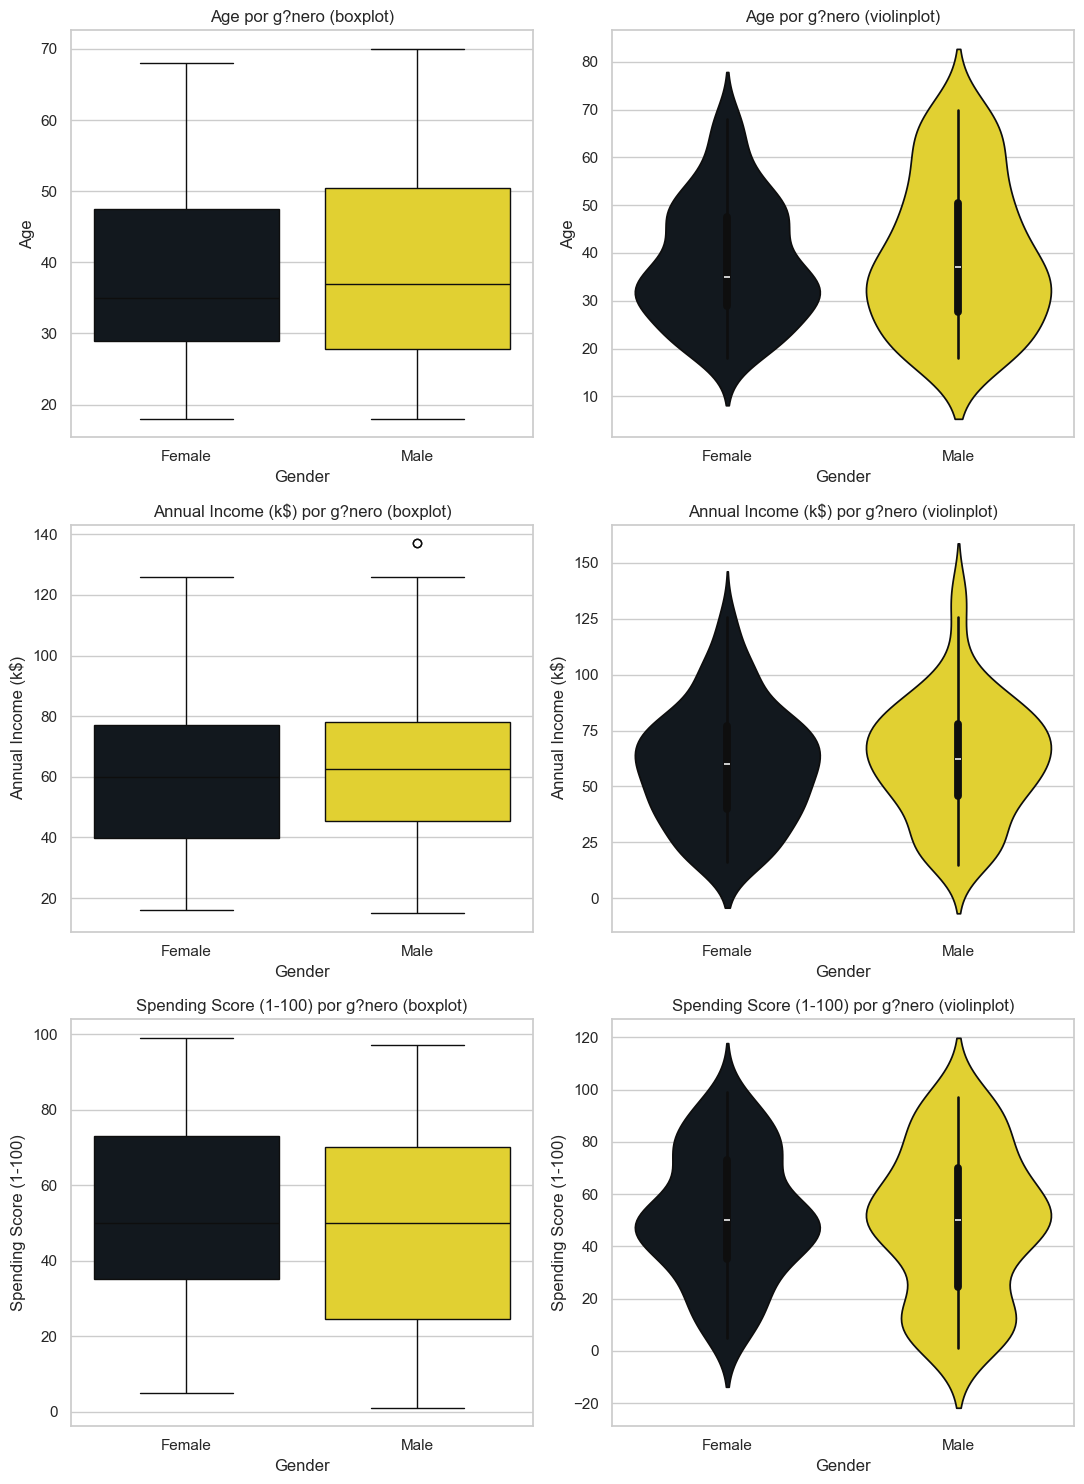

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(11, 15))

for row, feature in enumerate(numerical_features):
    sns.boxplot(data=df1, x='Gender', y=feature, order=['Female', 'Male'], hue='Gender', palette=colors, legend=False, ax=axes[row, 0])
    axes[row, 0].set_title(f'{feature} por género (boxplot)')

    sns.violinplot(data=df1, x='Gender', y=feature, order=['Female', 'Male'], hue='Gender', palette=colors, legend=False, ax=axes[row, 1])
    axes[row, 1].set_title(f'{feature} por género (violinplot)')

plt.tight_layout()
plt.show()

- Las edades abarcan de **18 a 68 años** en mujeres y de **18 a 70 años** en hombres; sus promedios son **38.10** y **39.81**, respectivamente.
- El ingreso anual medio es **59.25k** para mujeres y **62.23k** para hombres.
- El puntaje medio de gasto es **51.53** para mujeres y **48.51** para hombres.
- Las diferencias descriptivas entre géneros son pequeñas y no justifican por sí solas una segmentación separada.

### Características Numéricas vs Características Numéricas con respecto a la Característica Categórica :

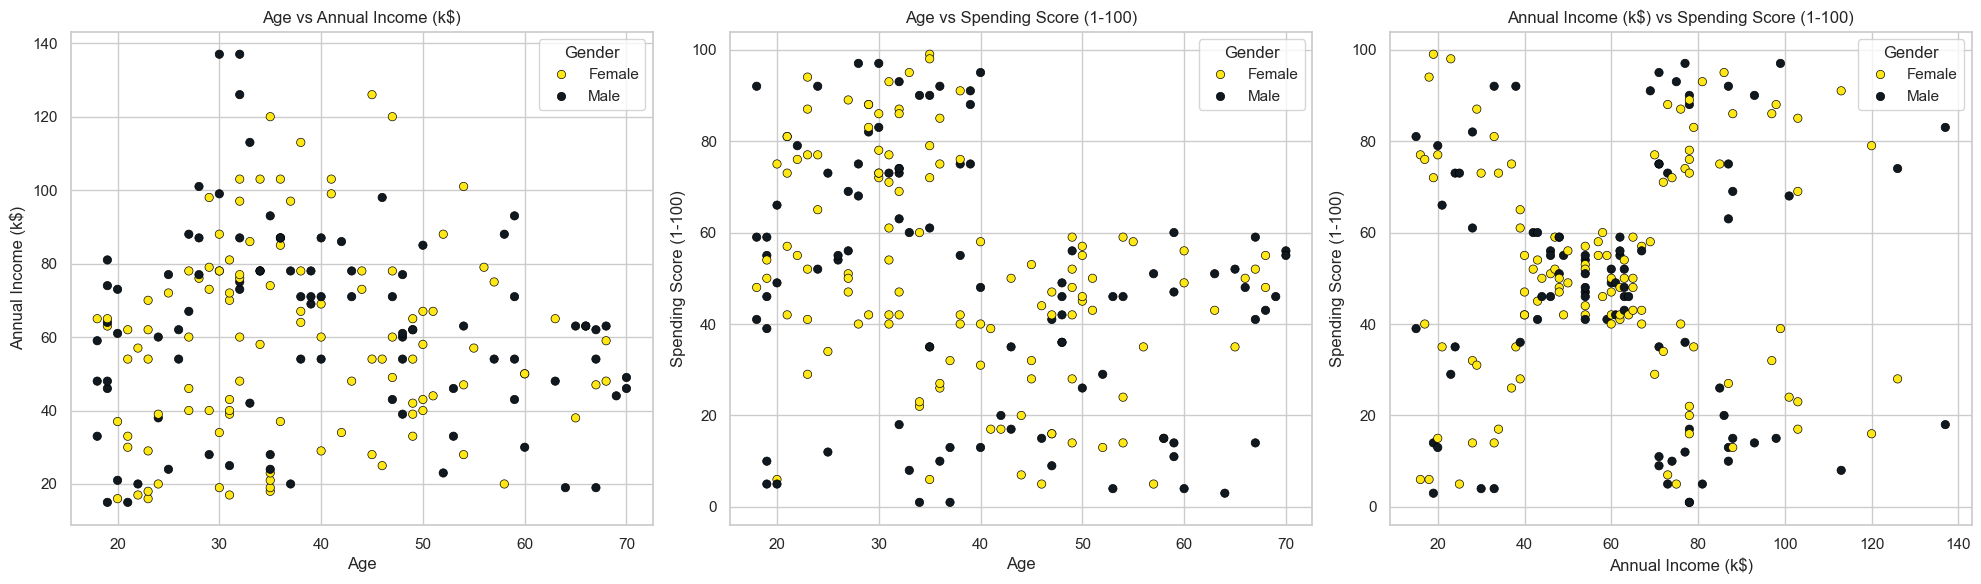

In [17]:
pairs = [
    ('Age', 'Annual Income (k$)'),
    ('Age', 'Spending Score (1-100)'),
    ('Annual Income (k$)', 'Spending Score (1-100)')
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
for ax, (x_feature, y_feature) in zip(axes, pairs):
    sns.scatterplot(
        data=df1,
        x=x_feature,
        y=y_feature,
        hue='Gender',
        hue_order=['Female', 'Male'],
        palette=colors,
        edgecolor='black',
        ax=ax
    )
    ax.set_title(f'{x_feature} vs {y_feature}')
plt.tight_layout()
plt.show()

- Los puntos de datos de **Annual Income (k\\$)** están presentes en todos los valores de **Edad**; **Gender** no aporta información significativa.
- Para **Spending Score (1-100)**, se puede observar claramente que los rangos de **Edad** **20 - 30** muestran hábitos de gasto muy altos.
- El grupo de **Edad** **30 - 40** destaca ambos extremos de los hábitos de gasto del cliente. El grupo de edad **40 - 70** muestra el otro extremo de hábitos de gasto con valores bajos.
- En la comparación **Annual Income (k\\$) vs Spending Score (1-100)** se pueden observar 5 grupos distintos. Para valores de **Annual Income (k\\$)** entre **0 y 40**, los datos muestran 2 grupos de clientes con **Spending Score (1-100)** entre **0 y 40** y entre **60 y 100**.
- Después de ese extremo, los datos destacan el grupo intermedio de clientes con **Annual Income (k\\$)** entre **40 y 70k** y **Spending Score (1-100)** entre **40 y 60**.
- Los valores de **Annual Income (k\\$)** entre **70 y 140k** definen el otro extremo, dividido en 2 grupos según los valores de **Spending Score (1-100)** (0-40 y 60-100).

# <center>Resumen del EDA</center>

- En los datos anteriores del centro comercial, las clientas **femeninas** son más que los clientes **masculinos**. Los datos de **Gender** están bastante equilibrados respecto a las demás características.
- Los clientes del centro comercial se pueden dividir por sus grupos de **Edad** :
    - **20 - 30** 
    - **30 - 40**
    - **40 - 70**. 
- La mediana de **Ingreso Anual (k\$)** de ambos **géneros** es aproximadamente **60k**. Muestra 3 grupos de valores : 
    - **0 - 40k** 
    - **40 - 70k**
    - **70 - 140k**.
- El **Spending Score (1-100)** de las clientas **femeninas** es mayor que el de los clientes **masculinos**. También puede dividir a los clientes en 3 grupos :
    - **0 - 40**
    - **40 - 60**
    - **60 - 100**
- Con la combinación de los valores anteriores, los **Clientes del Centro Comercial** pueden segmentarse, lo que permite atenderlos de forma más específica.

# <center>Ingeniería de Características</center>

### Matriz de Correlación :

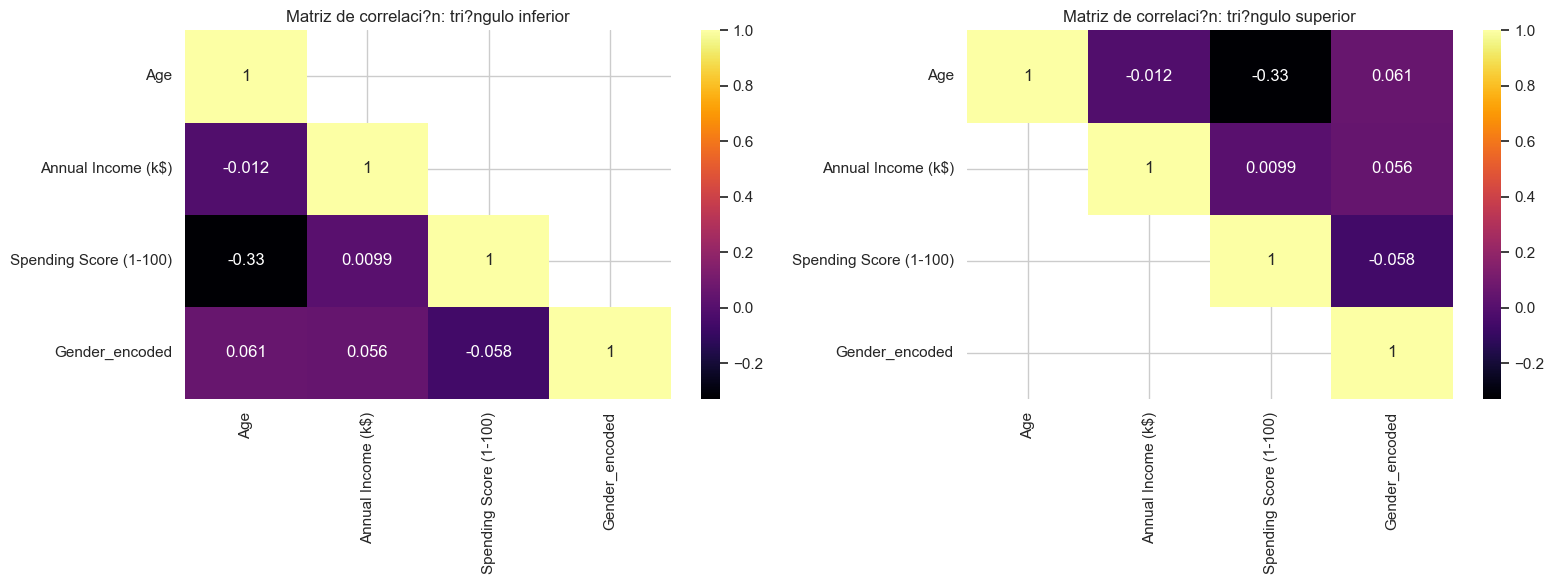

In [18]:
correlation_columns = numerical_features + ['Gender_encoded']
correlation_matrix = df1[correlation_columns].corr()
upper_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
lower_mask = np.tril(np.ones_like(correlation_matrix, dtype=bool), k=-1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
sns.heatmap(correlation_matrix, cmap='inferno', annot=True, mask=upper_mask, ax=axes[0])
axes[0].set_title('Matriz de correlación: triángulo inferior')
sns.heatmap(correlation_matrix, cmap='inferno', annot=True, mask=lower_mask, ax=axes[1])
axes[1].set_title('Matriz de correlación: triángulo superior')
plt.tight_layout()
plt.show()

- Las dos vistas corresponden a la misma matriz y muestran triángulos complementarios.
- **CustomerID** no se incluye porque es un identificador sin significado analítico.
- **Gender_encoded** mantiene correlaciones cercanas a cero con las variables numéricas.
- **Age** y **Spending Score (1-100)** presentan una correlación negativa: en este conjunto de datos, los clientes de mayor edad tienden a registrar menores puntajes de gasto.
- La correlación describe asociación lineal y no implica causalidad.

### Escalado de Datos :

- K-Means se basa en distancias, por lo que las variables con escalas mayores pueden dominar el resultado.
- Se utiliza **MinMaxScaler** para transformar **Age**, **Annual Income (k\$)** y **Spending Score (1-100)** al intervalo [0, 1].
- Se comparan los resultados originales y normalizados para mostrar el efecto del escalado.

In [19]:
mms = MinMaxScaler()
df2 = df1.copy(deep=True)
df2[numerical_features] = mms.fit_transform(df2[numerical_features])
df2[numerical_features].describe().loc[['min', 'max']]

,Age,Annual Income (k$),Spending Score (1-100)
min,0.0,0.0,0.0
max,1.0,1.0,1.0


- Para resaltar la diferencia en el rendimiento de los modelos cuando se entrenan con el conjunto de datos original y el conjunto normalizado, creamos una copia del conjunto original y aplicamos en ella la transformación de normalización.

**¡Ahora pasaremos a la sección de modelado!**

# <center>Modelado</center>

- **Aprendizaje No Supervisado**: es un problema donde la variable objetivo / característica es desconocida. Los problemas de **Aprendizaje No Supervisado** ocurren ampliamente en el ámbito médico, donde se toman múltiples lecturas y las enfermedades subyacentes son desconocidas.
- Por lo tanto, buscar patrones mediante técnicas de visualización nos ofrece información subyacente que no se puede comprender solo observando los datos tabulares.
- Sin embargo, cuando el tamaño de los conjuntos de datos es muy grande y hay demasiadas características, la visualización de datos puede ser una tarea tediosa. Por eso recurrimos al algoritmo de **K-Means Clustering**, que **no admite características categóricas**.
- Es el algoritmo más preferido para tratar el **Aprendizaje No Supervisado**, ya que encuentra clústeres/grupos en los datos mediante un enfoque matemático:
    - Selecciona 2 centroides aleatoriamente (supongamos k = 2).
    - Se calcula la distancia entre los centroides y todos los puntos de datos.
    - Si el punto de datos está más cerca de uno de los centroides, se etiqueta con ese centroide y viceversa.
    - Para los 2 clústeres formados, se calcula el valor promedio de los puntos agrupados y esos valores promedio definen los nuevos clústeres.
    - Este proceso se repite hasta que ambos centroides convergen en puntos fijos.
- El hiperparámetro **k** define el número de clústeres o grupos en los que se divide el dato. Para seleccionar valores de **k**, usamos 2 pruebas estadísticas:
    - **Método del codo**: es un método que grafica la suma de errores al cuadrado para un rango de valores de **k**. Si este gráfico parece un brazo, se selecciona el valor de **k** que se asemeja a un **codo**. A partir de ese valor de **codo**, la suma de valores al cuadrado (inercia) comienza a disminuir de forma lineal y se considera un valor óptimo.
    - **Método de la puntuación de silueta**: evalúa la calidad de los clústeres en términos de qué tan bien se agrupan los puntos de datos con otros puntos similares. Esta puntuación se calcula usando la fórmula de distancia y se selecciona el valor de **k** con la puntuación más alta para el modelado.

**Ahora crearemos modelos entrenándolos con las combinaciones de características seleccionadas a partir de las pruebas anteriores y también los visualizaremos.**

In [20]:
# K-Means recibe exclusivamente las tres características numéricas.
df1_model = df1[numerical_features].copy()
df2_model = df2[numerical_features].copy()

### <center>Edad - Ingreso Anual (k\$)</center>

In [21]:
m1 = df1_model[['Age', 'Annual Income (k$)']].values  # Datos originales
m2 = df2_model[['Age', 'Annual Income (k$)']].values  # Datos normalizados

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

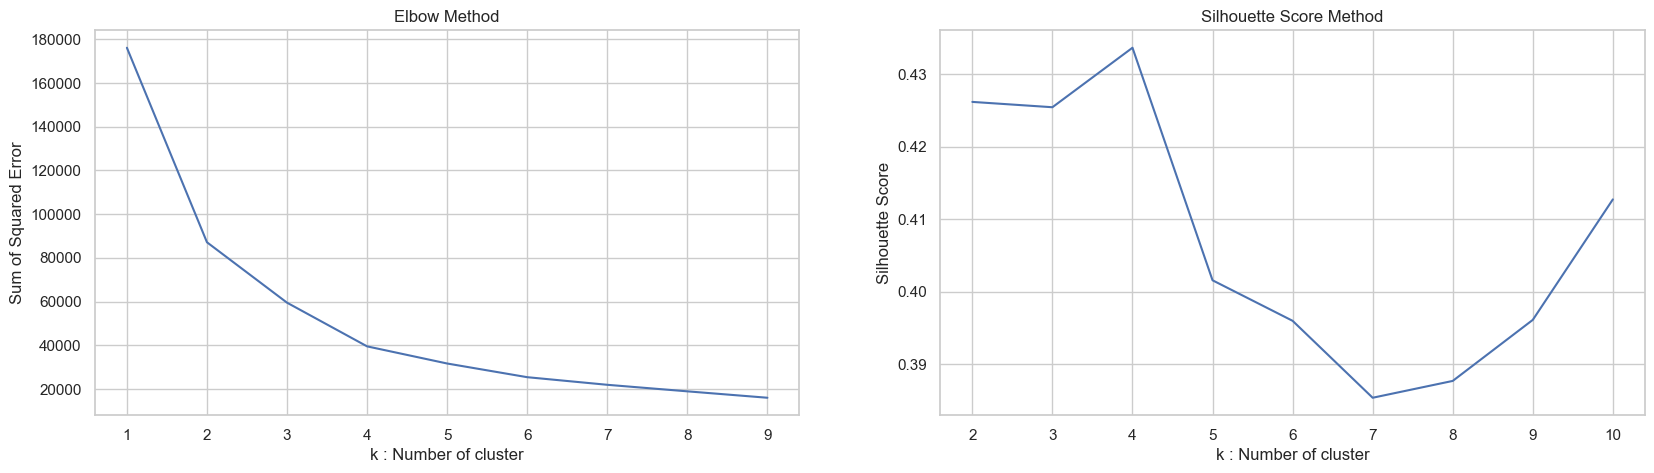

In [22]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

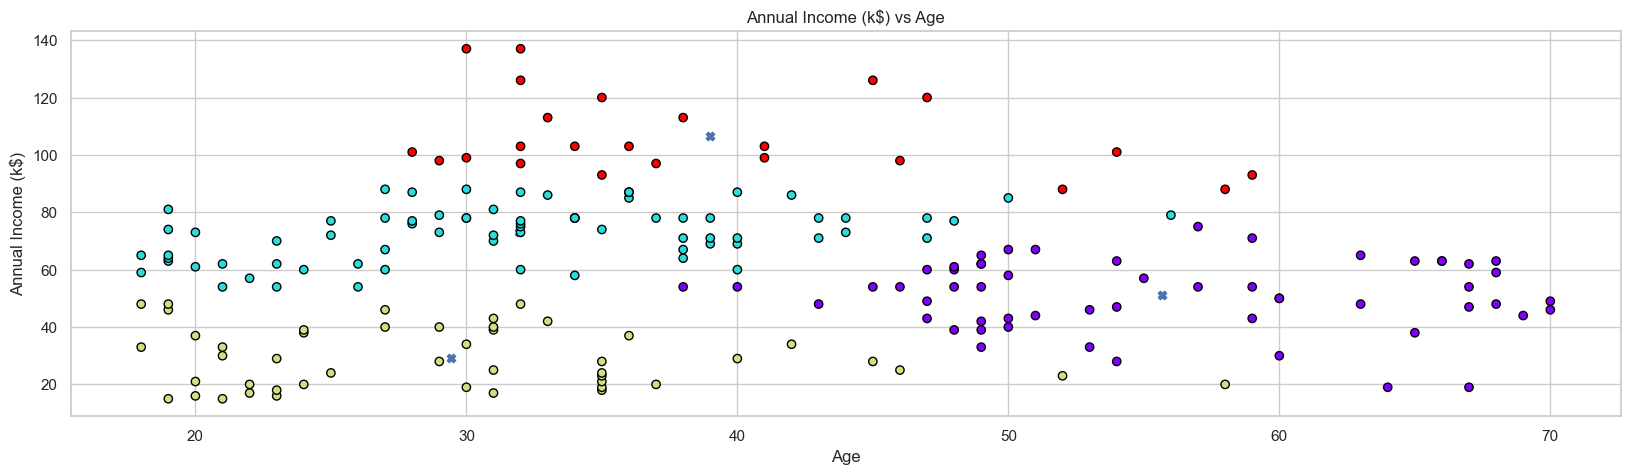

In [23]:
model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Age'], df1['Annual Income (k$)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Ingreso anual (k$) vs edad')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

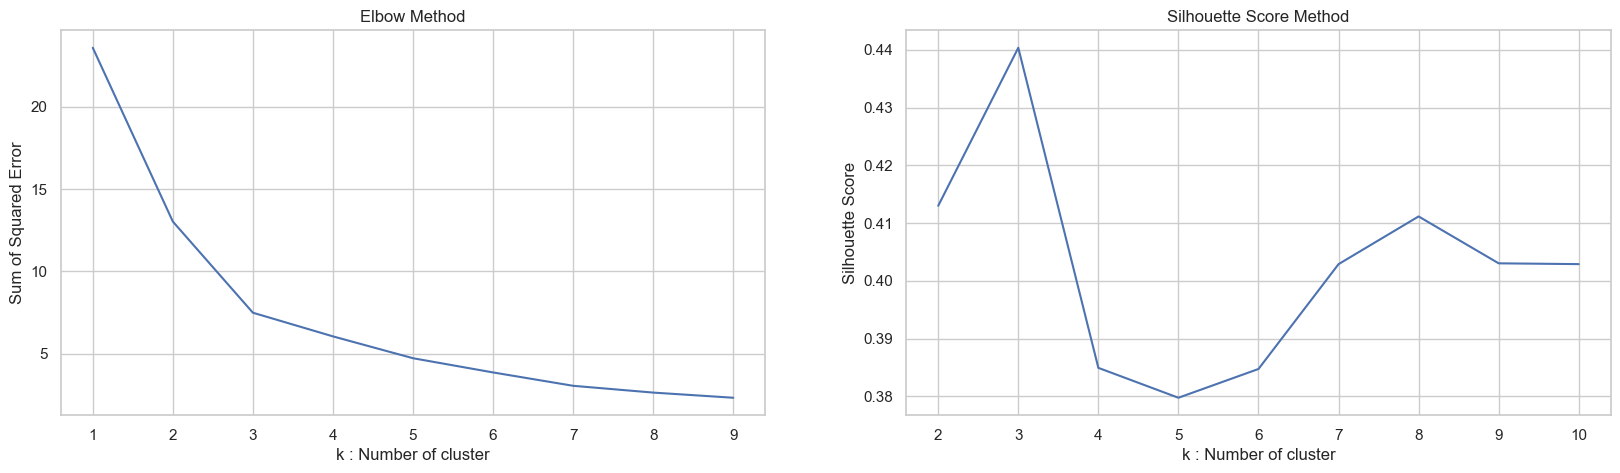

In [24]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 3**

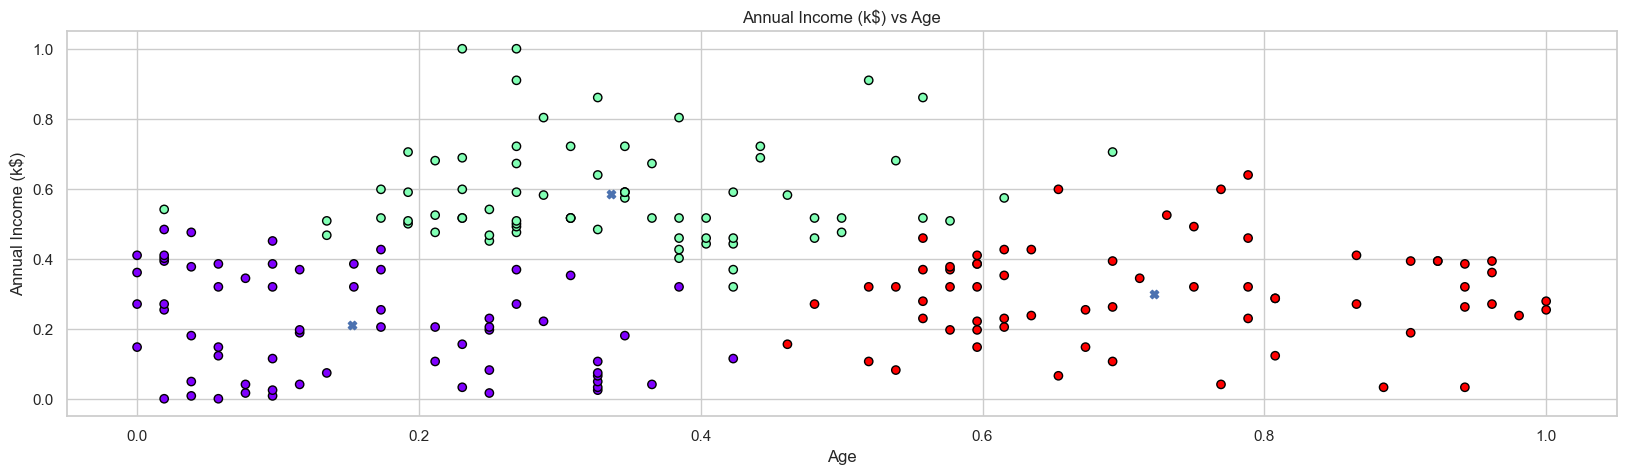

In [25]:
model = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Age'], df2['Annual Income (k$)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Ingreso anual (k$) vs edad')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### <center>Edad - Puntaje de Gasto (1-100)</center>

In [26]:
m1 = df1_model[['Age', 'Spending Score (1-100)']].values  # Datos originales
m2 = df2_model[['Age', 'Spending Score (1-100)']].values  # Datos normalizados

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

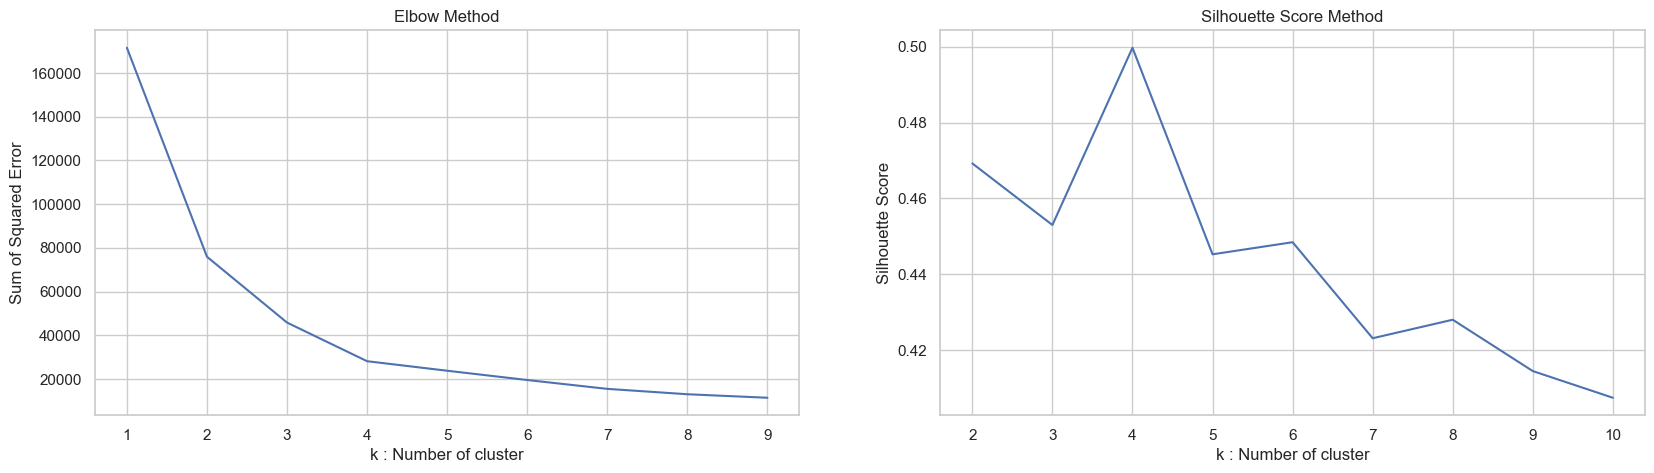

In [27]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

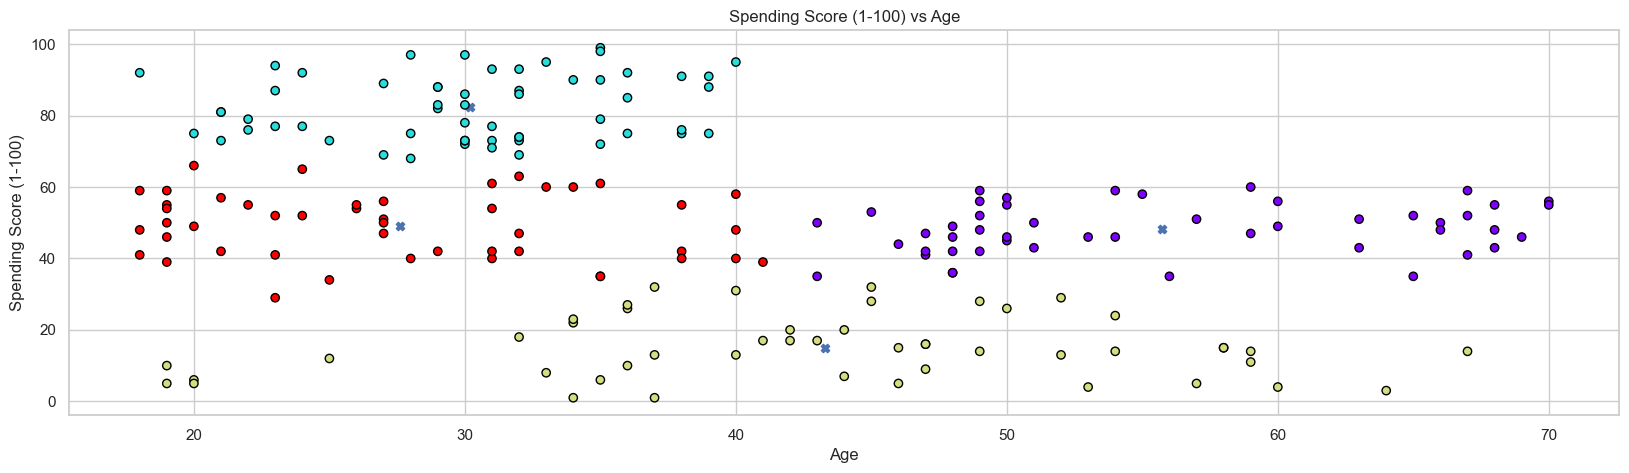

In [28]:
model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Age'], df1['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Puntaje de gasto (1-100) vs edad')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

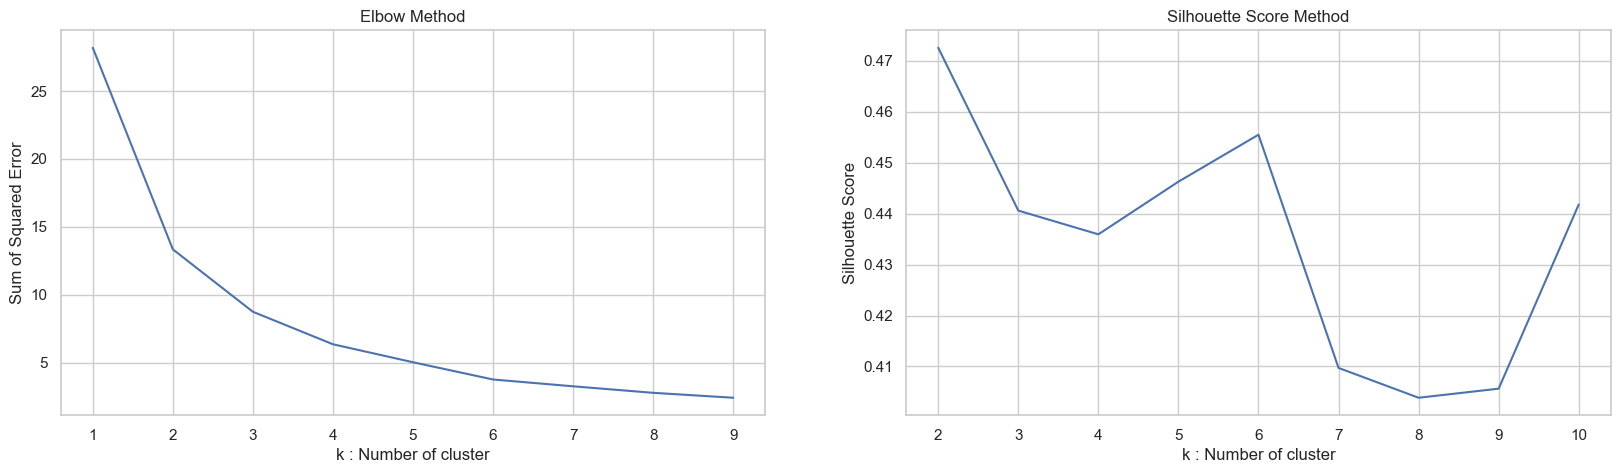

In [29]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- La mayor puntuación de silueta para los datos normalizados se obtiene con:
    - **k: clústeres = 2**

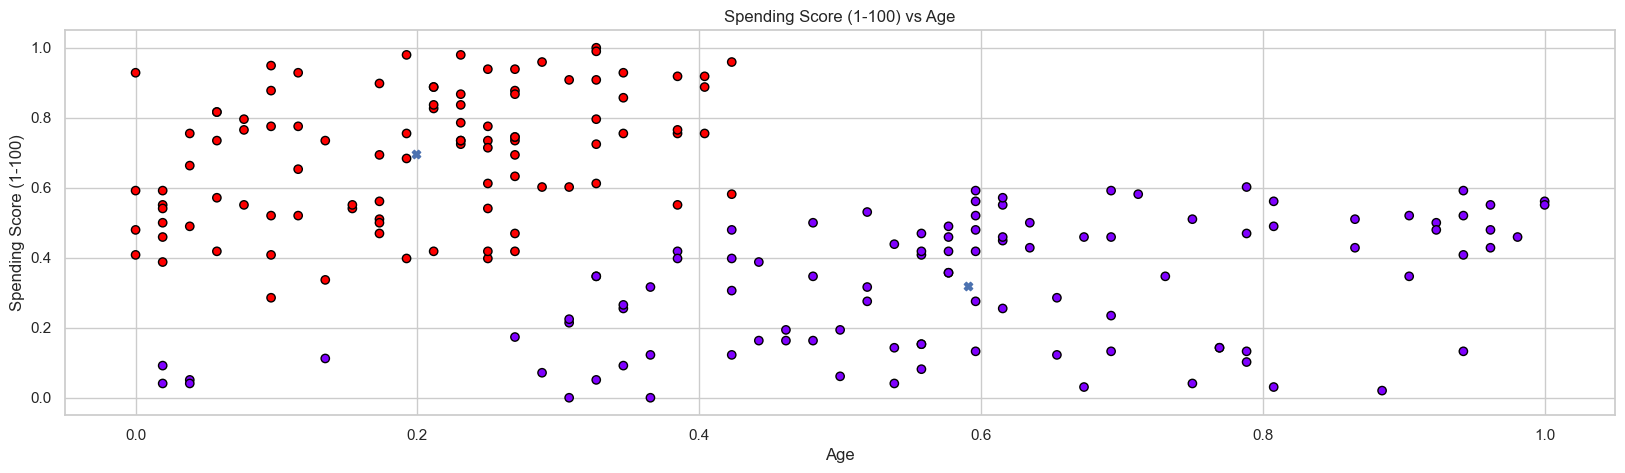

In [30]:
model = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Age'], df2['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Puntaje de gasto (1-100) vs edad')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Ingreso Anual (k\$) - Puntaje de Gasto (1-100)</center>

In [31]:
m1 = df1_model[['Annual Income (k$)', 'Spending Score (1-100)']].values  # Datos originales
m2 = df2_model[['Annual Income (k$)', 'Spending Score (1-100)']].values  # Datos normalizados

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

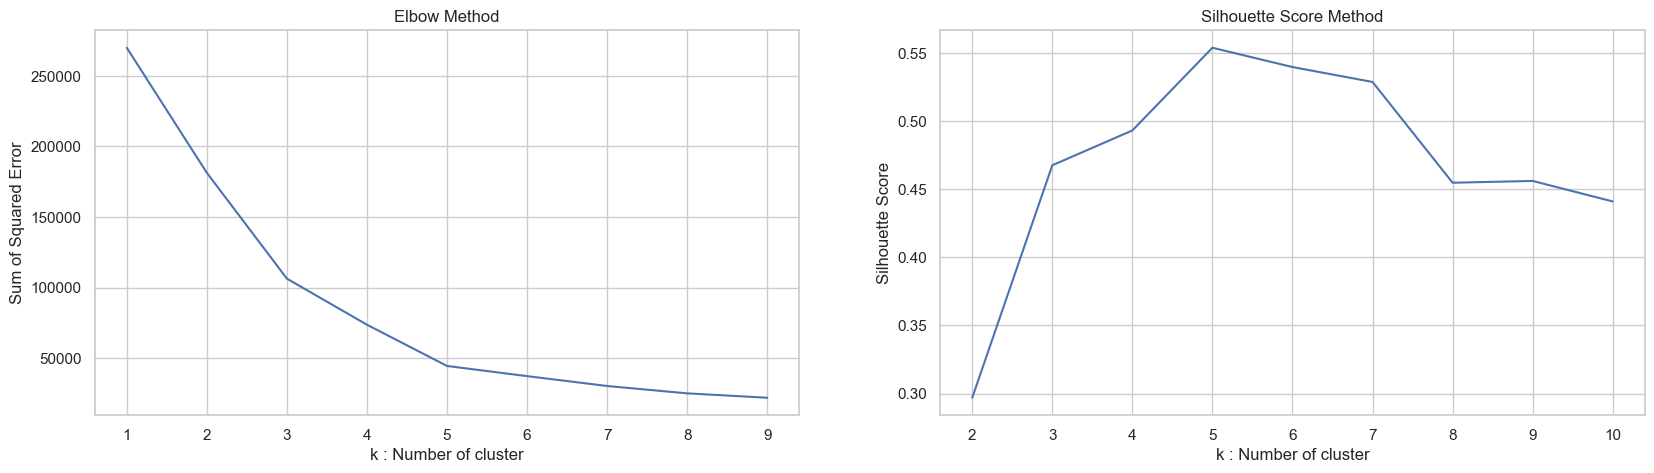

In [32]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

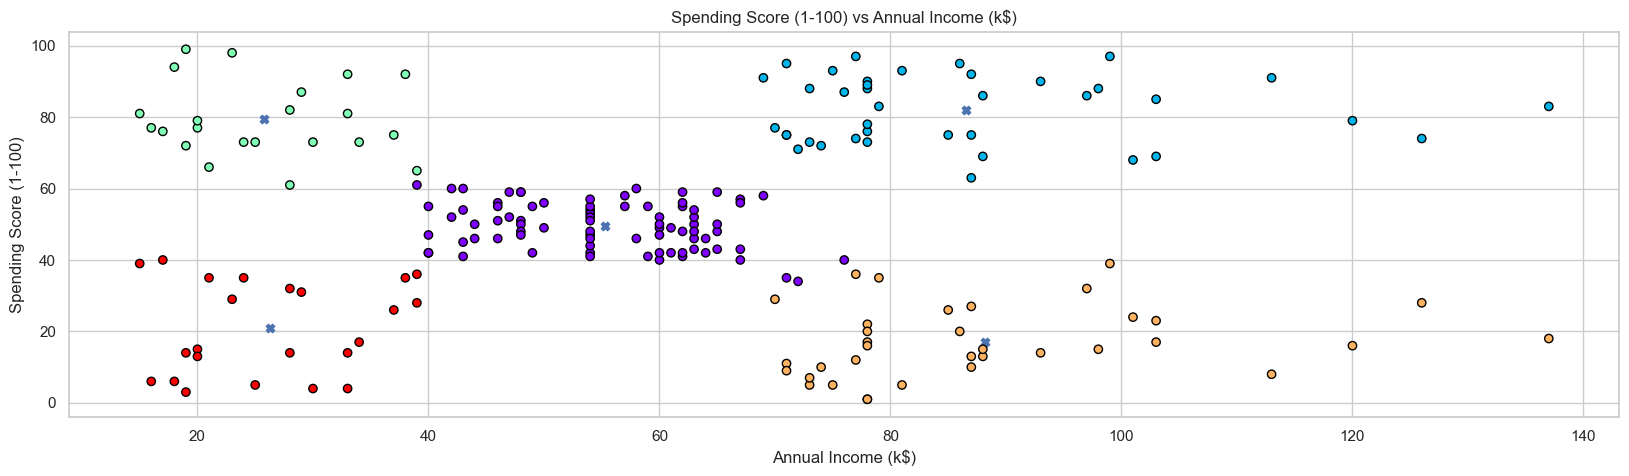

In [33]:
model = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Annual Income (k$)'], df1['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Puntaje de gasto (1-100) vs ingreso anual (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

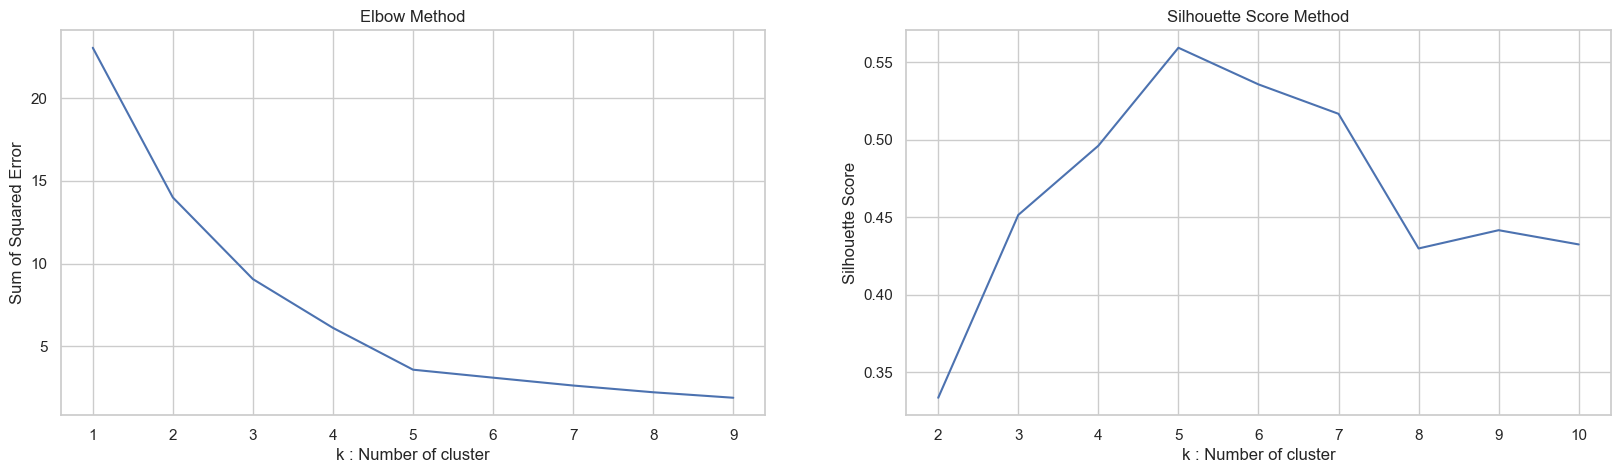

In [34]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

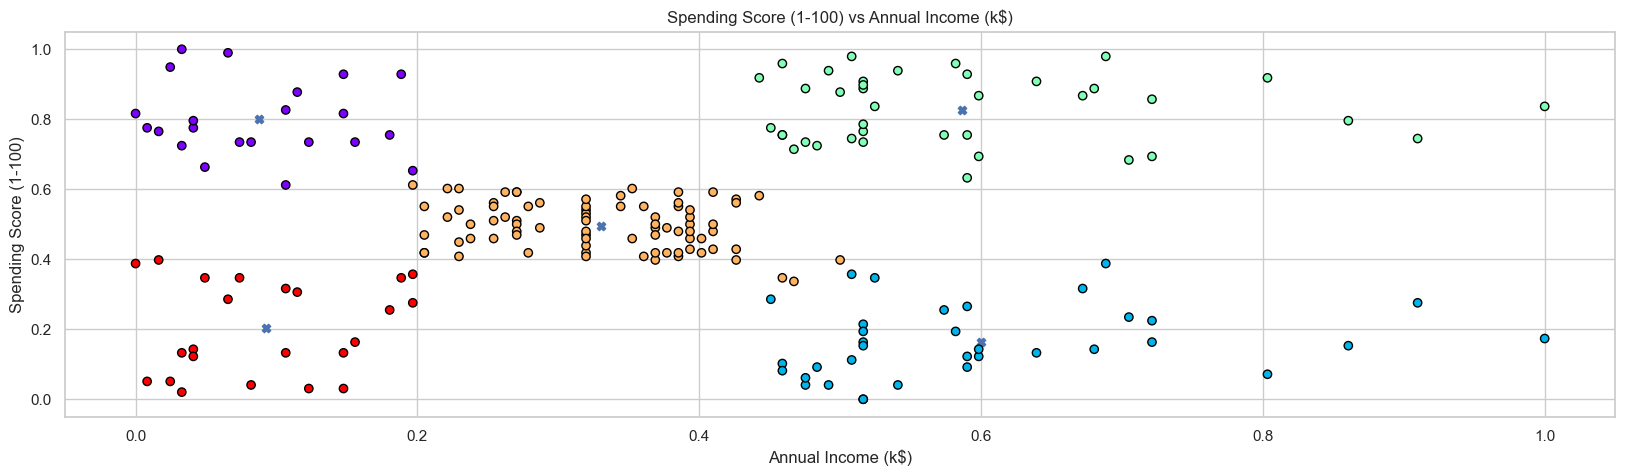

In [35]:
model = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Annual Income (k$)'], df2['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Puntaje de gasto (1-100) vs ingreso anual (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Edad - Ingreso Anual (k\$) - Puntaje de Gasto (1-100)</center>

In [36]:
m1 = df1_model[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].values  # Datos originales
m2 = df2_model[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].values  # Datos normalizados

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

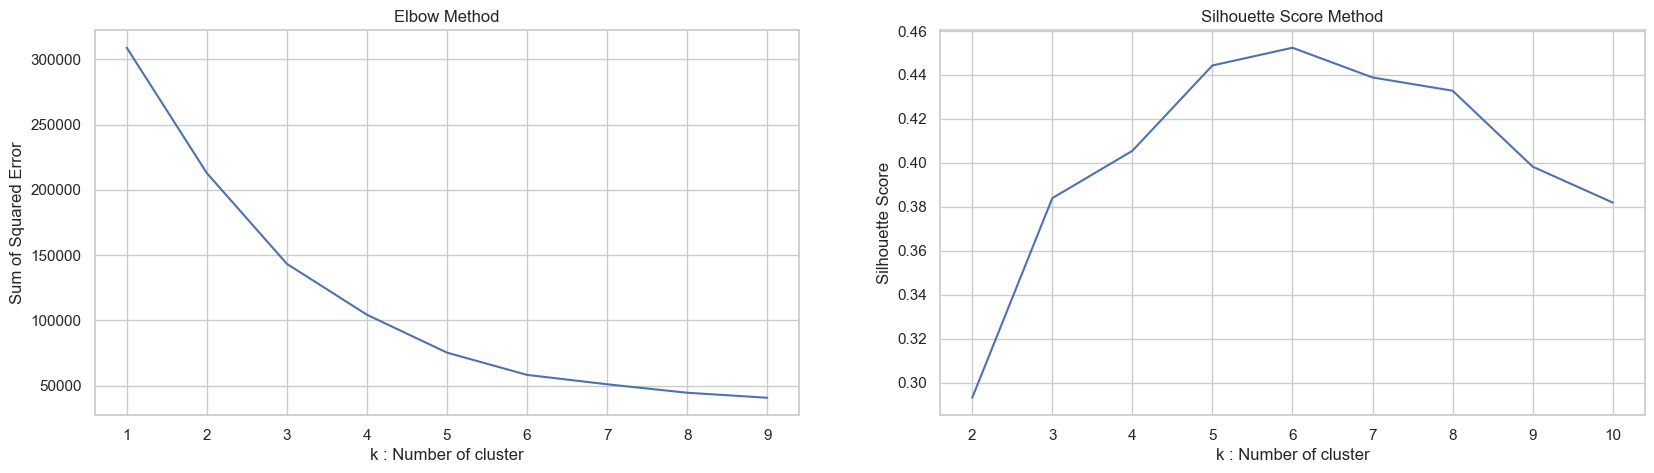

In [37]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

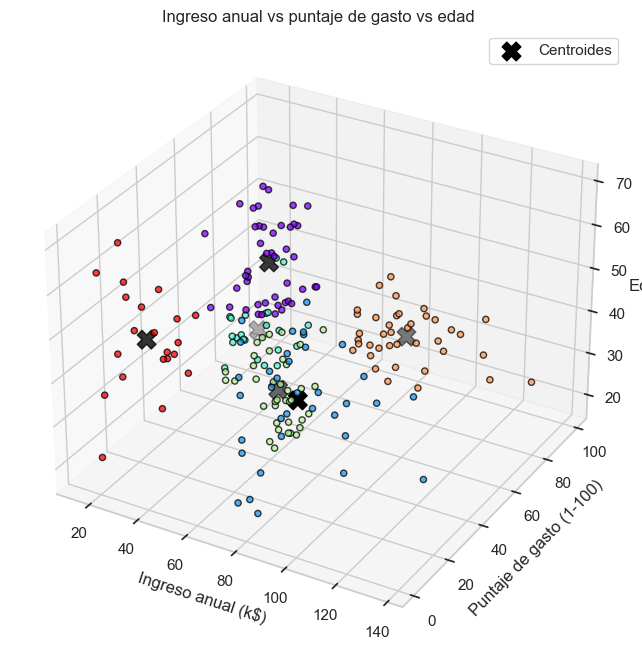

In [38]:
model = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
labels = model.fit_predict(m1)
centroids = model.cluster_centers_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(m1[:, 0], m1[:, 1], m1[:, 2], c=labels, cmap='rainbow', edgecolor='black', alpha=0.75)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker='X', s=180, color='black', label='Centroides')
ax.set_title('Ingreso anual vs puntaje de gasto vs edad')
ax.set_xlabel('Ingreso anual (k$)')
ax.set_ylabel('Puntaje de gasto (1-100)')
ax.set_zlabel('Edad')
ax.legend()
plt.show()

### Conjunto de datos normalizado

#### Método del codo y método de la puntuación de silueta :

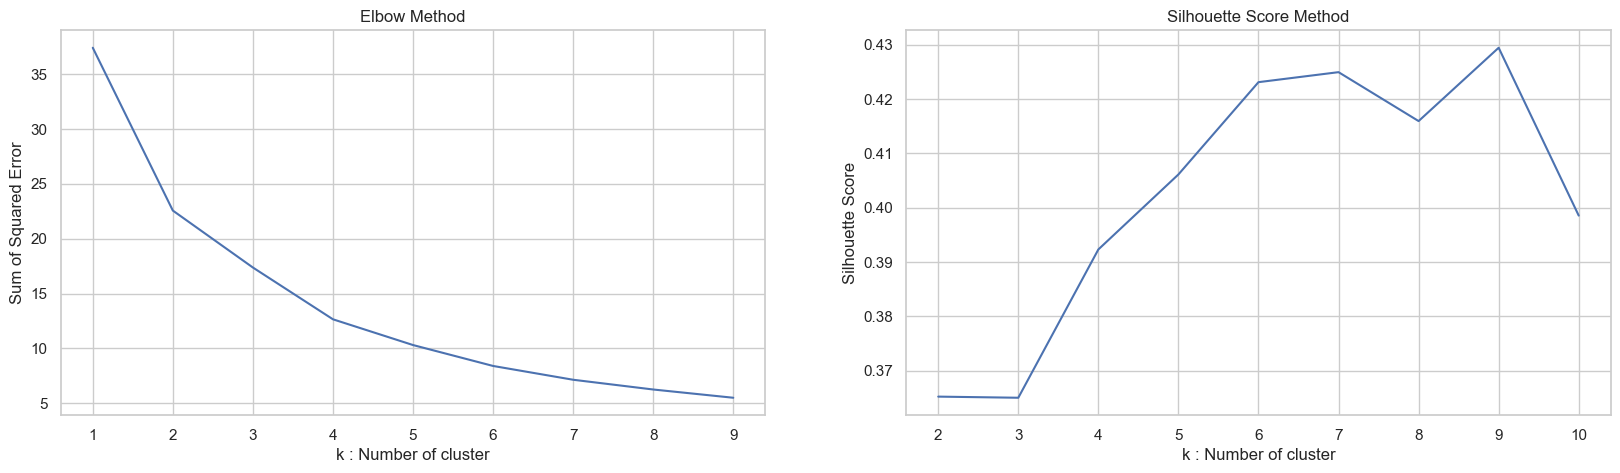

In [39]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Método del codo :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Método del codo')
plt.xlabel("k: número de clústeres")
plt.ylabel("Suma de errores cuadrados (inercia)")

# Método de la puntuación de silueta
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Método de la puntuación de silueta')
plt.xlabel("k: número de clústeres")
plt.ylabel("Silhouette Score")
plt.show()

- La mayor puntuación de silueta para los datos normalizados se obtiene con:
    - **k: clústeres = 9**

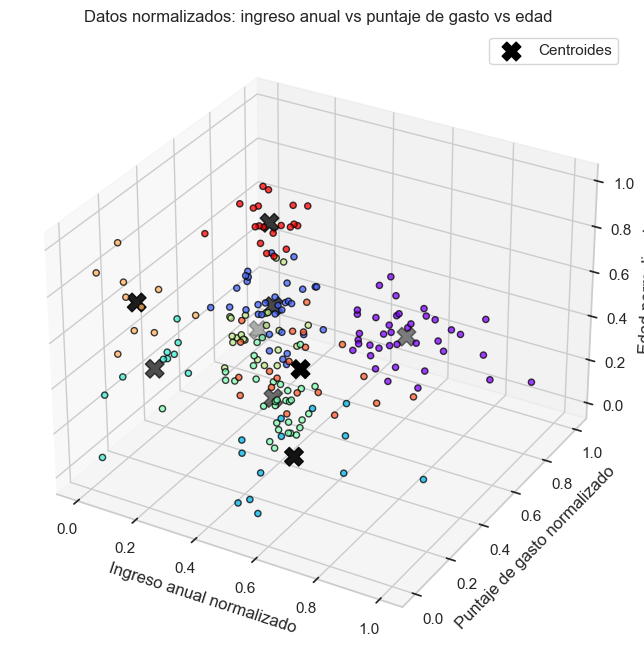

In [40]:
model = KMeans(n_clusters=9, random_state=RANDOM_STATE, n_init=N_INIT, max_iter=1000)
labels = model.fit_predict(m2)
centroids = model.cluster_centers_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(m2[:, 0], m2[:, 1], m2[:, 2], c=labels, cmap='rainbow', edgecolor='black', alpha=0.75)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker='X', s=180, color='black', label='Centroides')
ax.set_title('Datos normalizados: ingreso anual vs puntaje de gasto vs edad')
ax.set_xlabel('Ingreso anual normalizado')
ax.set_ylabel('Puntaje de gasto normalizado')
ax.set_zlabel('Edad normalizada')
ax.legend()
plt.show()

### <center>Tabla de resultados</center>

Los valores se seleccionan mediante la mayor puntuación de silueta obtenida con `random_state=42` y `n_init=10`.

#### Conjunto de datos original

| # | Combinación de características | Número de clústeres |
|---:|---|---:|
| 1 | Edad - Ingreso anual (k\$) | 4 |
| 2 | Edad - Puntaje de gasto (1-100) | 4 |
| 3 | Ingreso anual (k\$) - Puntaje de gasto (1-100) | 5 |
| 4 | Edad - Ingreso anual (k\$) - Puntaje de gasto (1-100) | 6 |

#### Conjunto de datos normalizado

| # | Combinación de características | Número de clústeres |
|---:|---|---:|
| 1 | Edad - Ingreso anual (k\$) | 3 |
| 2 | Edad - Puntaje de gasto (1-100) | 2 |
| 3 | Ingreso anual (k\$) - Puntaje de gasto (1-100) | 5 |
| 4 | Edad - Ingreso anual (k\$) - Puntaje de gasto (1-100) | 9 |

# <center>Conclusión</center>

- El conjunto permite estudiar segmentación de clientes mediante aprendizaje no supervisado.
- La combinación **Ingreso anual - Puntaje de gasto** produce una separación clara de cinco grupos tanto en datos originales como normalizados.
- El escalado sí puede cambiar la solución cuando las variables tienen rangos distintos; por ejemplo, **Edad - Puntaje de gasto** pasa de cuatro a dos clústeres según la mayor puntuación de silueta.
- Los resultados son reproducibles porque todos los modelos utilizan `random_state=42` y `n_init=10`.
- Los clústeres describen patrones del conjunto de datos, pero deben interpretarse con conocimiento del negocio antes de definir estrategias comerciales.